In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv('Customer Churn.csv')

In [31]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Replacing blanks with 0 and no data charges were recorded

In [27]:
df['TotalCharges'] = df['TotalCharges'].replace(" ",0)
df['TotalCharges'] = df['TotalCharges'].astype("float")

In [30]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [33]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [35]:
df['customerID'].duplicated().sum()

np.int64(0)

In [39]:
def conv(value):
    if value==1:
        return "Yes"
    else: 
        return "No"

df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Converted 0 and 1 to yes and no in SeniorCitizen

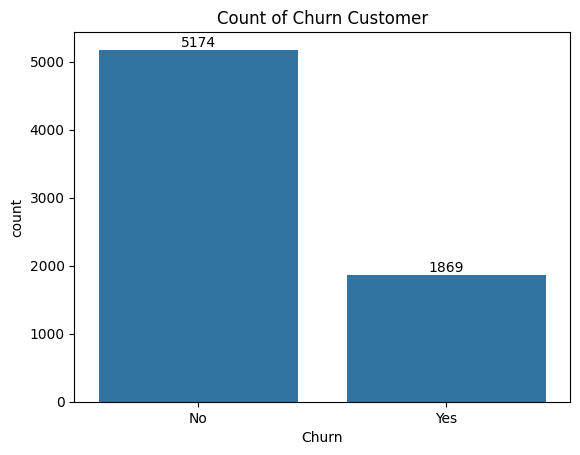

In [53]:
ax = sns.countplot(x = df['Churn'], data=df)
ax.bar_label(ax.containers[0])
plt.title("Count of Churn Customer")
plt.show()

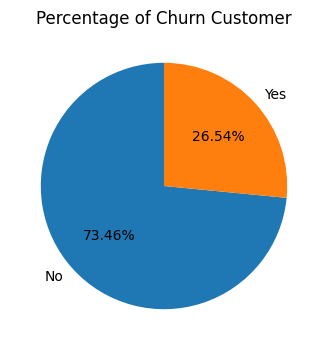

In [59]:
plt.figure(figsize =(4,4))

gb = df.groupby('Churn').agg({'Churn':"count"})

plt.title("Percentage of Churn Customer")
plt.pie(gb['Churn'],
       startangle =  90,
       labels = gb.index,
       autopct = "%1.2f%%")
plt.show()

### From the given pie chart 26.54% customer are churned reasons are :

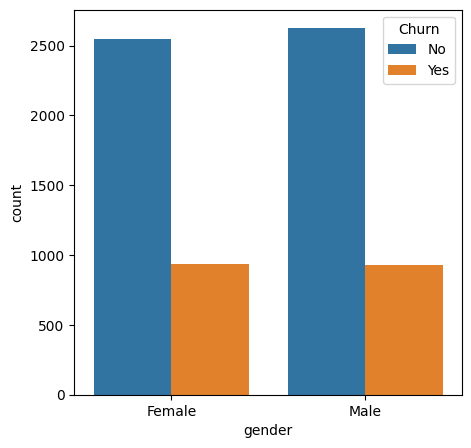

In [65]:
plt.figure(figsize=(5,5))
sns.countplot(x = "gender",
              data = df,
             hue = "Churn")
plt.show()

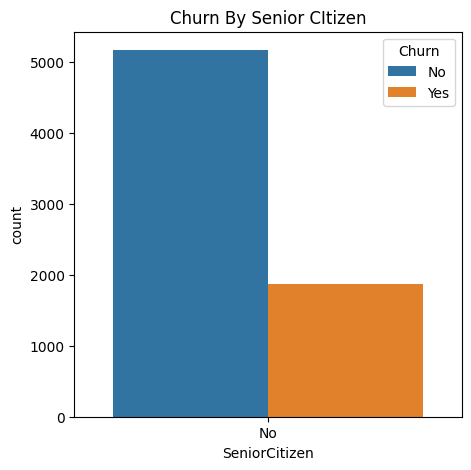

In [69]:
 plt.figure(figsize=(5,5))

sns.countplot(x = "SeniorCitizen",
              data = df,
             hue = "Churn")
plt.title("Churn By Senior CItizen")
plt.show()

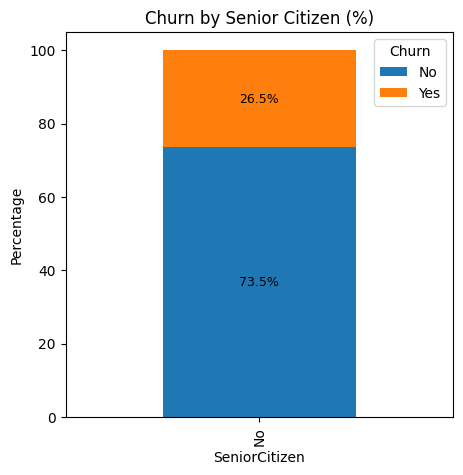

In [77]:
import pandas as pd
import matplotlib.pyplot as plt

# Create percentage table
ct = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100

# Plot stacked bar chart
ax = ct.plot(kind="bar", stacked=True, figsize=(5,5))

# Add percentage labels on bars
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x = p.get_x()
    y = p.get_y()

    if height > 0:
        ax.text(
            x + width/2,
            y + height/2,
            f"{height:.1f}%",
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Churn by Senior Citizen (%)")
plt.ylabel("Percentage")
plt.legend(title="Churn")
plt.show()

## comparatively greater percentage of people have churned

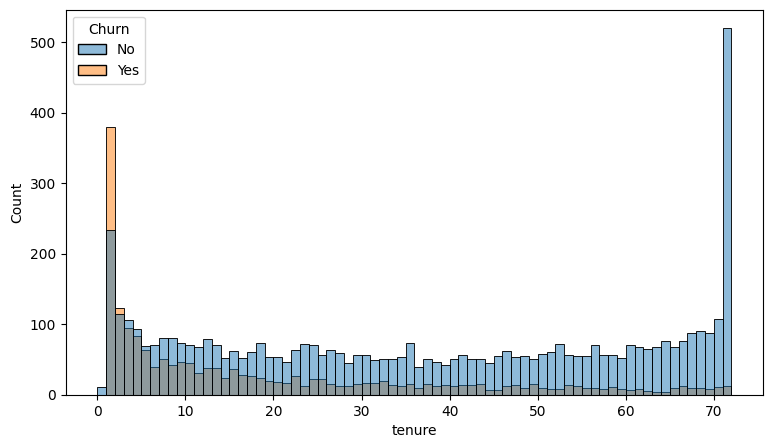

In [91]:
plt.figure(figsize =(9,5))
sns.histplot(x = "tenure",
           bins = 72,
           hue ="Churn",
           data = df)
plt.show()

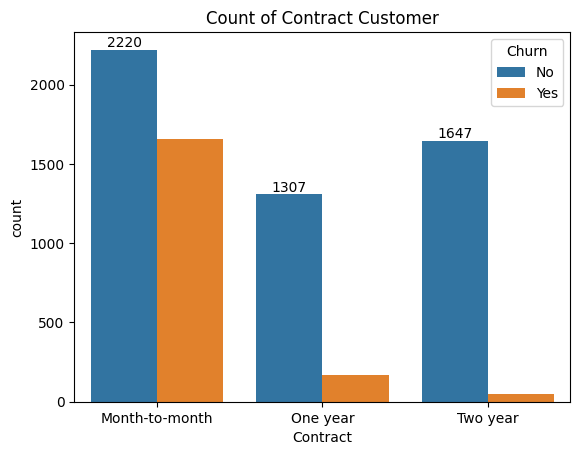

In [96]:
ax = sns.countplot(x = "Contract",
                   hue = "Churn",
                   data=df)
ax.bar_label(ax.containers[0])
plt.title("Count of Contract Customer")
plt.show()

### People in month to month contract have churned more compared to others

In [97]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

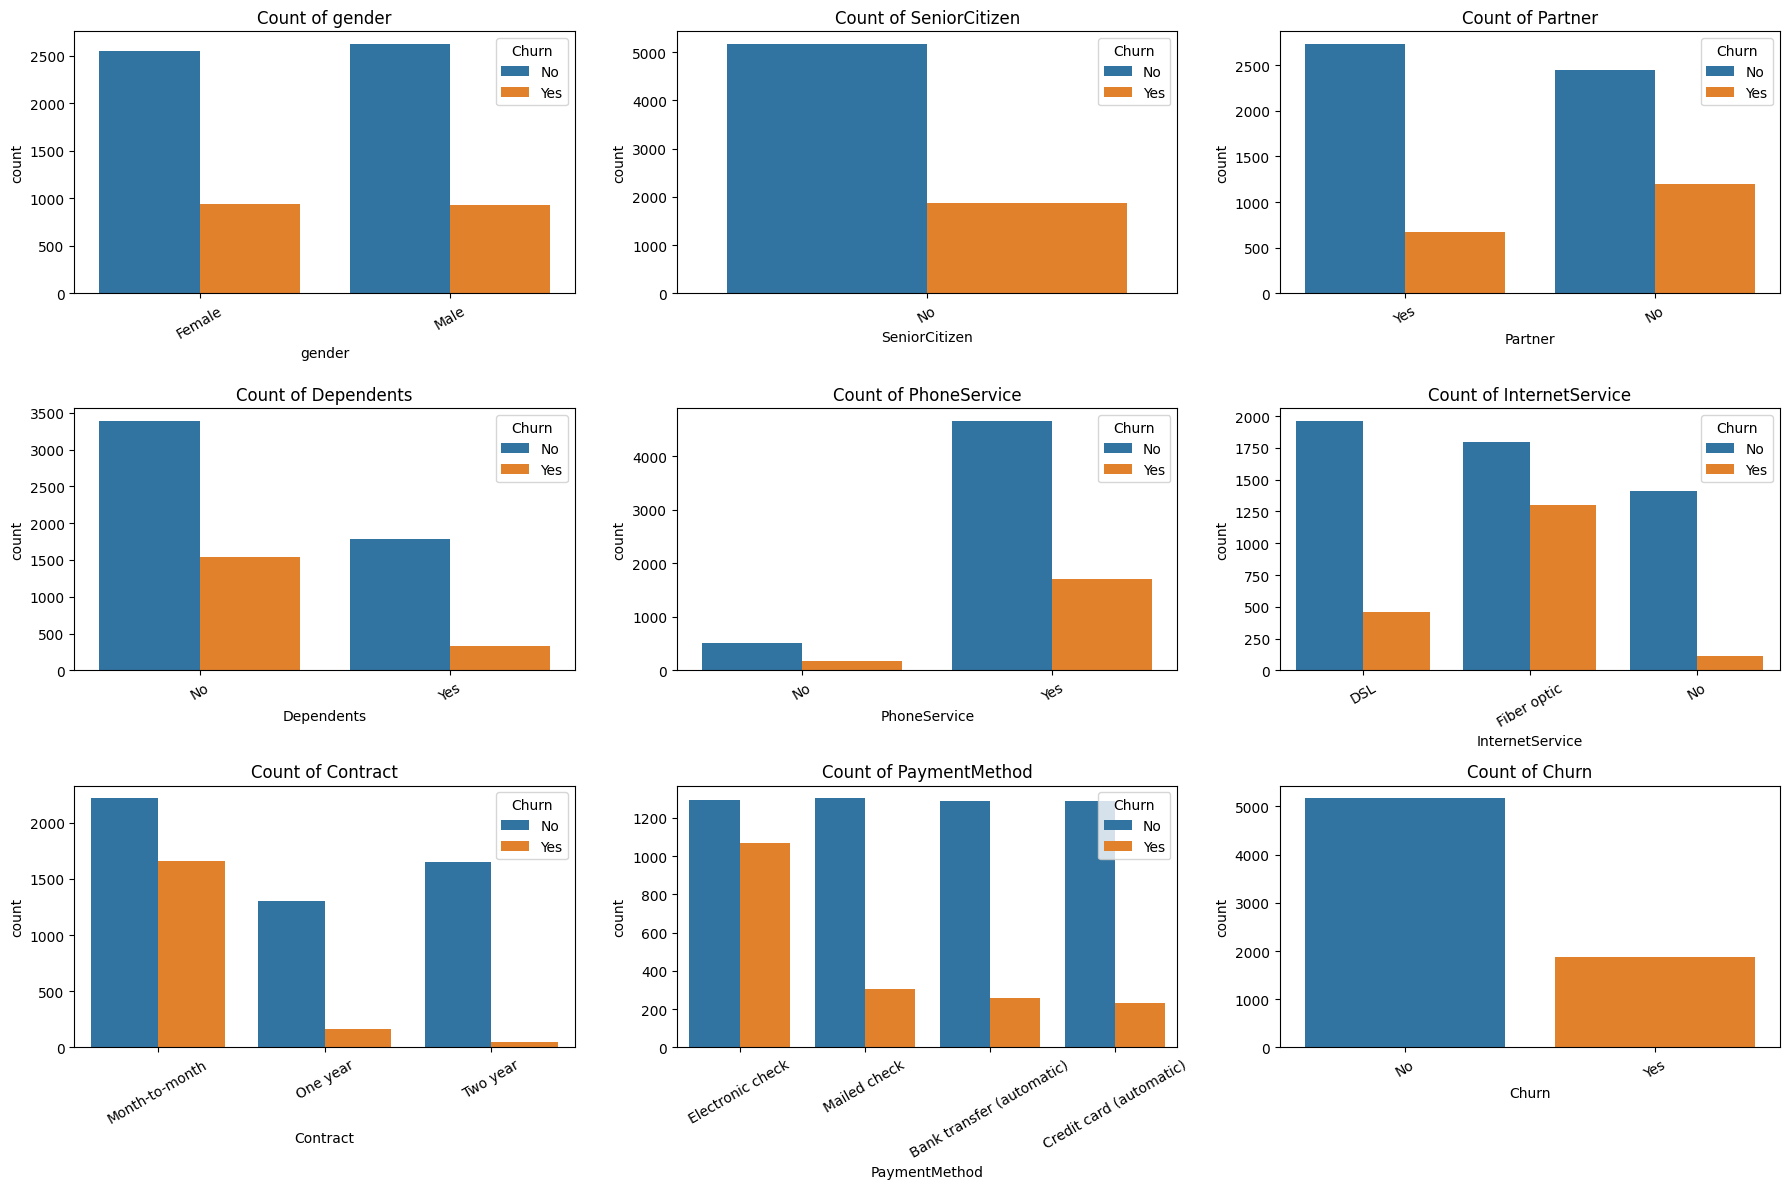

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

# categorical columns to plot
cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'InternetService',
    'Contract', 'PaymentMethod', 'Churn'
]

# subplot size
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i],hue = "Churn")
    axes[i].set_title(f'Count of {col}')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

#### 1.The dataset shows that churned customers are fewer than non-churned customers, but churn is still significant in some groups.
#### 2.Customers with Month-to-month contracts and Electronic Check payment method show the highest churn tendency.
#### 3.Users with Fiber optic internet service have higher churn compared to DSL or no internet users.
#### 4.Customers without dependents or partners are more likely to churn than those with family support.
#### 5.Overall, contract type, internet service, and payment method are the strongest indicators of churn behavior.

